In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
from scipy import stats

def perform_welch(list_a, list_b):

    t_stat, p_value = stats.ttest_ind(list_a, list_b, equal_var=False)

    # Significance encoding
    if p_value < 0.001:
        stars = '***'
    elif p_value < 0.01:
        stars = '**'
    elif p_value < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    print(f"Welch's t-test results")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value:     {p_value:.4g}")
    print(f"significance:{stars}")


In [3]:
DATASET = 'toiam'

#### 1. AUC over LNK curve

In [4]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = np.trapz(np.array(l))

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = np.trapz(np.array(l))

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 6.2673
p-value:     0.0004171
significance:***


#### 2. Best LNK value

In [5]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = max(l)

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = max(l)

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 2.1674
p-value:     0.06687
significance:ns


/home/constantin/miniconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


#### 3. LNK value after first epoch

In [6]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = l[0]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = l[0]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 0.9850
p-value:     0.344
significance:ns


#### 4. LNK value after last measured epoch

In [7]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = l[-1]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = l[-1]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 2.1408
p-value:     0.06955
significance:ns


/home/constantin/miniconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


#### 5. LNK value at maximum counterfactual and treatment

In [8]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

IndexError: list index out of range

In [9]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: -2.0605
p-value:     0.07767
significance:ns


#### 6. Per-Epoch t-test

In [10]:
withs = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()
    print(len(l))
    withs.append(l)

withouts = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()
    print(len(l))
    withouts.append(l)


min_len_with  = min(len(x) for x in withs)
min_len_without = min(len(x) for x in withouts)
L = min(min_len_with, min_len_without)

withs_arr    = np.array([x[:L] for x in withs], dtype=float)
withouts_arr = np.array([x[:L] for x in withouts], dtype=float)

for idx in range(L):
    a = withs_arr[:, idx]
    b = withouts_arr[:, idx]
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    print(idx, t_stat, p_value, sep="\t")

100
100
100
100
100
100
100
100
30
70
44
77
72
59
77
70
0	0.984988606017238	0.3440492722548758
1	0.5413898371571815	0.5972146035700749
2	3.8584574697459195	0.0033534743489311487
3	0.605090706685531	0.5578825631568174
4	0.9247995034988463	0.37737499391507046
5	2.660562390021704	0.0187082572567164
6	1.195141694826609	0.25496452676226533
7	4.981901641373361	0.00029612667407653403
8	0.0891085704244685	0.9306416628751175
9	2.489395206184913	0.03967625362506143
10	0.6699300861297558	0.5185294598017642
11	4.392005337981932	0.0007783328456565651
12	2.6748294044575	0.028705282038223055
13	2.4227894649622894	0.03162847083998593
14	3.347193848796671	0.010578826486480284
15	7.561379844034471	4.129302963442682e-06
16	1.914067886657255	0.09412140535095556
17	4.092400477709455	0.004024677382569796
18	12.774886983079075	7.489918861038263e-09
19	5.175583155277227	0.001199864074906289
20	11.61260790340443	1.5010421073312712e-08
21	5.727759790915627	0.0003993738472485686
22	13.726106520087013	6.868320526

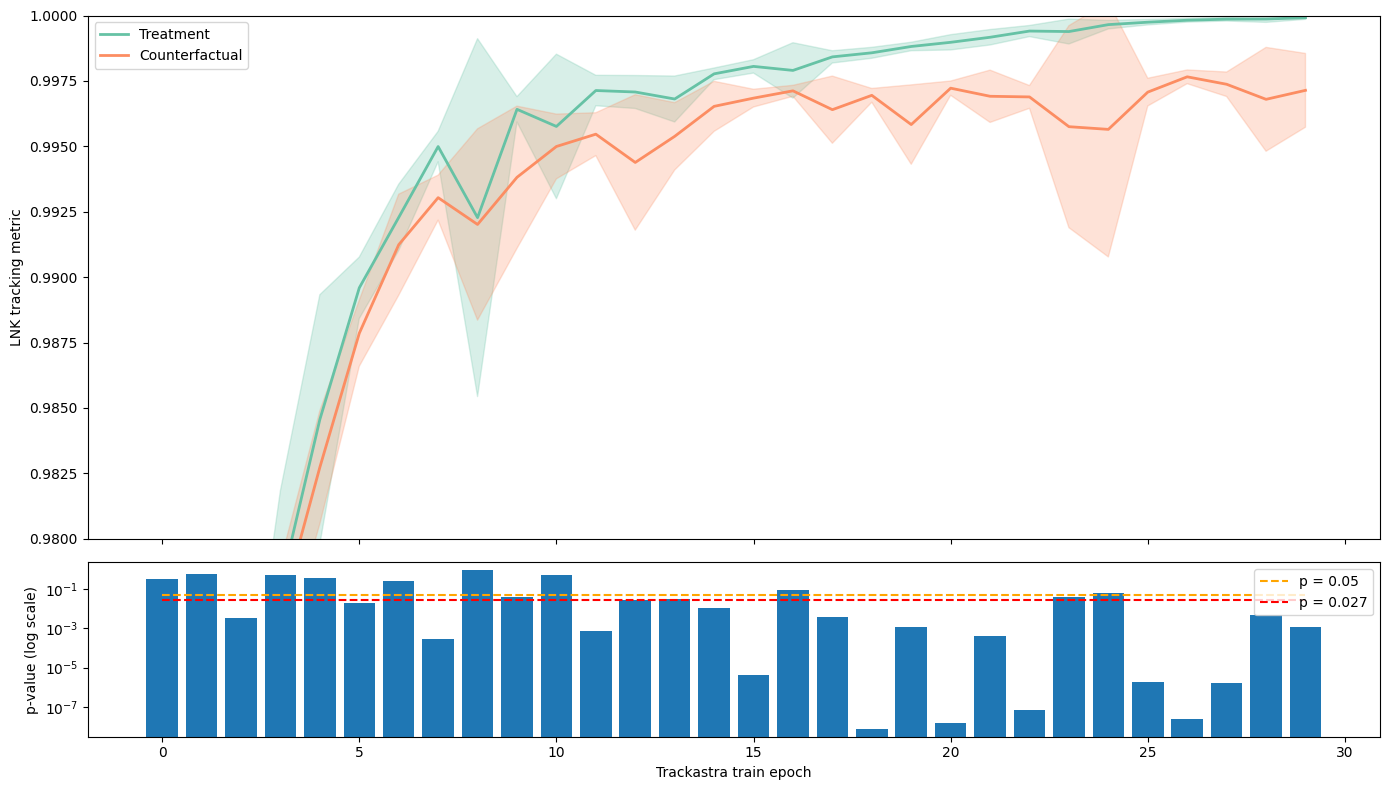

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

# -------------------------
# 1) Load your runs (WITH / WITHOUT)
# -------------------------
withs = []
for fname in sorted(os.listdir(f"effects/{DATASET}/with/")):
    df = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    withs.append(df["LNK"].to_numpy())

withouts = []
for fname in sorted(os.listdir(f"effects/{DATASET}/without/")):
    df = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    withouts.append(df["LNK"].to_numpy())

# Ensure all runs have the same length (truncate to min length if not)
minlen = min(min(map(len, withs)), min(map(len, withouts)))
withs = np.stack([x[:minlen] for x in withs], axis=0)       # shape: (n_runs, T)
withouts = np.stack([x[:minlen] for x in withouts], axis=0) # shape: (n_runs, T)

# -------------------------
# 2) Plot helper: mean ± std shading
# -------------------------
cmap = mpl.colormaps["Set2"]
ca, cb = cmap(0), cmap(1)

def plot_mean_shaded(ax, arr2d, color, label):
    """
    arr2d: shape (n_runs, T)
    """
    mean = arr2d.mean(axis=0)
    std  = arr2d.std(axis=0, ddof=0)
    x = np.arange(arr2d.shape[1])

    ax.plot(x, mean, color=color, label=label, linewidth=2)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.25)

# -------------------------
# 3) Compute per-index p-values (Welch by default; set equal_var=True for Student)
# -------------------------
pvals = np.empty(minlen, dtype=float)
tstats = np.empty(minlen, dtype=float)

for idx in range(minlen):
    w = withs[:, idx]
    wo = withouts[:, idx]
    res = stats.ttest_ind(w, wo, equal_var=False, nan_policy="omit")
    tstats[idx] = res.statistic
    pvals[idx]  = res.pvalue

x = np.arange(minlen)

# -------------------------
# 4) Build the combined figure (top: means; bottom: significance)
# -------------------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- TOP ---
plot_mean_shaded(ax_top, withs, ca, "Treatment")
plot_mean_shaded(ax_top, withouts, cb, "Counterfactual")
ax_top.set_ylabel("LNK tracking metric")  # or "Score" / your metric name
# Optional: uncomment if you want the same y-limits as your example
# ax_top.set_ylim(0.90, 1.0)
ax_top.legend(loc="best")

# --- BOTTOM ---
ax_bottom.bar(x, pvals)
ax_bottom.set_yscale("log")
ax_bottom.set_ylabel("p-value (log scale)")
ax_bottom.set_xlabel("Trackastra train epoch")


ymin = 0.98
ymax = 1.0

ax_top.set_ylim(ymin, ymax)

# threshold lines
ax_bottom.hlines(0.05, x.min(), x.max(), color="orange", linestyle="--", label="p = 0.05")
ax_bottom.hlines(0.027, x.min(), x.max(), color="red", linestyle="--", label="p = 0.027")
ax_bottom.legend(loc="upper right")

fig.tight_layout()
plt.savefig("fin_time_TOIAM.pdf", bbox_inches="tight")
plt.show()
